In [1]:
# ➡ Step 1: Prepare (or generate) data
# ➡ Step 2: Initialize parameters
# ➡ Step 3: Define prediction function
# ➡ Step 4: Define cost function
# ➡ Step 5: Compute gradients
# ➡ Step 6: Update parameters (gradient descent)
# ➡ Step 7: Train over multiple epochs
# ➡ Step 8: Plot line + loss


✅ Step 1: Prepare the Data

In [ ]:
#X = [1,2,3,4,5]
#y =[3,6,9,12,15]

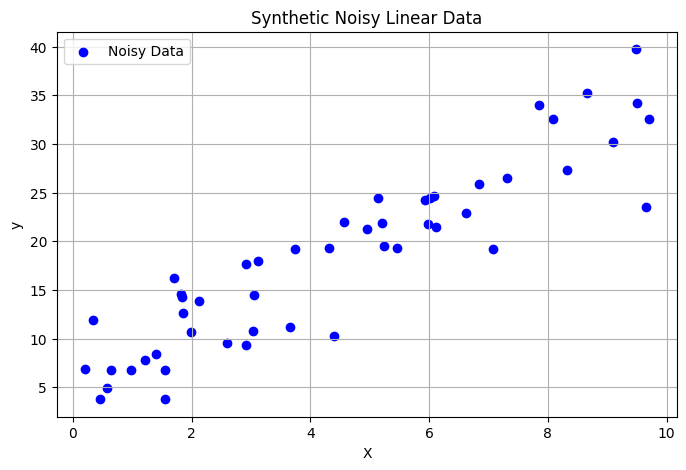

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate 50 random X values between 0 and 10
X = np.random.rand(50) * 10

# True relationship: y = 3x + 5, but add random noise
true_w = 3
true_b = 5
noise = np.random.randn(50) * 4  # Add Gaussian noise
y = true_w * X + true_b + noise

# Visualize the noisy data
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Noisy Data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Noisy Linear Data')
plt.grid(True)
plt.legend()
plt.show()


✅ Step 2: Initialize Parameters 'w'and'b'


In [4]:
import numpy as np

#w = np.random.randn()
#b = np.random.rand()
w = 0.0
b = 0.0
print(w)
print(b)

0.0
0.0


✅ Step 3: Define Prediction Function

In [6]:
def predict(w, b, x):
    return w*x + b

print(predict(w, b, 2))

0.0


In [8]:
def print_predictions():
    for i in range(len(X)):
        y_hat = predict(w, b, X[i])
        print(f"x: {X[i]}, y: {y[i]}, prediction: {y_hat}")

✅ Step 4: Define the Loss / Cost Function

In [9]:
def compute_cost(X, y, w, b):
    n  = len(X)
    total_error = 0
    for i in range(n):
        y_hat = predict(w, b, X[i])
        error = y_hat - y[i]
        total_error += error**2
    cost = total_error / n
    return cost

print(compute_cost(X, y, w, b))

66.0


✅ Step 5: Compute the Gradients (Derivatives)

In [10]:
def compute_gradients(X, y, w, b):
    n = len(X)
    dw = 0.0
    db = 0.0
    for i in range(n):
        y_hat =predict(w, b, X[i])
        error = y_hat - y[i]
        dw += error *X[i]
        db += error
    dw = (2/n) * dw
    db = (2/n) * db
    return dw, db

✅ Step 6: Gradient Descent — Update Parameters

In [11]:
def update_parameters(w , b, dw, db, learning_rate):
    w = w - (learning_rate * dw)
    b = b - (learning_rate * db)
    return w, b

✅ Step 7: Training the Model over Epochs

In [21]:
def train(X, y , w, b , learning_rate, epochs):
    for epoch in range(epochs):
        cost = compute_cost(X, y, w, b)
        dw , db = compute_gradients(X, y, w, b)
        w, b = update_parameters(w, b, dw, db, learning_rate)
        print(f"Epoch {epoch+1}: Cost={cost:.4f}, w={w:.4f}, b={b:.4f}")
    return w, b

In [24]:
learning_rate = 0.01
epochs = 1000

w_final, b_final = train(X, y,w, b, learning_rate, epochs)
print(f"Y = {round(w_final, 2)} . x + {round(b_final, 2)}")

Epoch 1: Cost=419.7624, w=2.1140, b=0.3673
Epoch 2: Cost=91.8303, w=3.0088, b=0.5387
Epoch 3: Cost=32.6981, w=3.3861, b=0.6270
Epoch 4: Cost=21.9858, w=3.5437, b=0.6797
Epoch 5: Cost=19.9962, w=3.6082, b=0.7174
Epoch 6: Cost=19.5784, w=3.6331, b=0.7486
Epoch 7: Cost=19.4444, w=3.6413, b=0.7769
Epoch 8: Cost=19.3622, w=3.6423, b=0.8040
Epoch 9: Cost=19.2901, w=3.6404, b=0.8304
Epoch 10: Cost=19.2203, w=3.6371, b=0.8564
Epoch 11: Cost=19.1517, w=3.6334, b=0.8822
Epoch 12: Cost=19.0838, w=3.6295, b=0.9079
Epoch 13: Cost=19.0168, w=3.6255, b=0.9333
Epoch 14: Cost=18.9505, w=3.6214, b=0.9586
Epoch 15: Cost=18.8850, w=3.6174, b=0.9838
Epoch 16: Cost=18.8202, w=3.6134, b=1.0088
Epoch 17: Cost=18.7561, w=3.6094, b=1.0337
Epoch 18: Cost=18.6928, w=3.6054, b=1.0585
Epoch 19: Cost=18.6302, w=3.6015, b=1.0831
Epoch 20: Cost=18.5683, w=3.5976, b=1.1075
Epoch 21: Cost=18.5071, w=3.5936, b=1.1318
Epoch 22: Cost=18.4466, w=3.5898, b=1.1560
Epoch 23: Cost=18.3868, w=3.5859, b=1.1801
Epoch 24: Cost=18.3

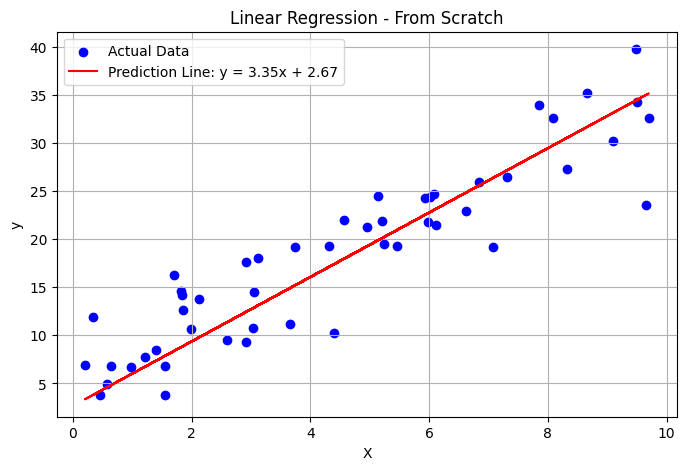

In [23]:
import matplotlib.pyplot as plt

# Original data
X_data = X  # your input list [1, 2, 3, 4, 5]
y_data = y  # your actual output [2, 4, 6, 8, 10]

# Predicted line using final weights
y_pred_line = [w_final * x + b_final for x in X_data]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(X_data, y_data, color='blue', label='Actual Data')
plt.plot(X_data, y_pred_line, color='red', label=f'Prediction Line: y = {w_final:.2f}x + {b_final:.2f}')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression - From Scratch')
plt.legend()
plt.grid(True)
plt.show()


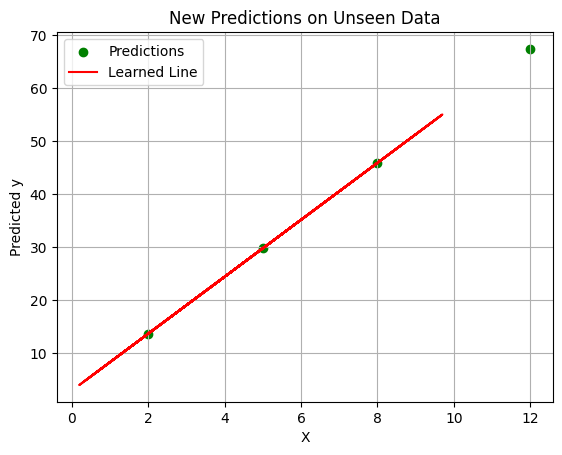

In [27]:
new_X = np.array([2, 5, 8, 12])
predicted_y = [predict(x, w_final, b_final) for x in new_X]

plt.scatter(new_X, predicted_y, color='green', label='Predictions')
plt.plot(X, [predict(x, w_final, b_final) for x in X], color='red', label='Learned Line')
plt.xlabel("X")
plt.ylabel("Predicted y")
plt.legend()
plt.grid(True)
plt.title("New Predictions on Unseen Data")
plt.show()


In [28]:
from sklearn.linear_model import LinearRegression
import numpy as np

X_reshaped = np.array(X).reshape(-1, 1)
y_array = np.array(y)
model = LinearRegression()
model.fit(X_reshaped, y_array)

w_sklearn = model.coef_[0]
b_sklearn = model.intercept_

print(f"scikit-learn model: y = {w_sklearn:.2f}x + {b_sklearn:.2f}")

scikit-learn model: y = 2.91x + 5.39


In [30]:
# Predict using sklearn
y_pred_sklearn = model.predict(X_reshaped)

# Predict using your model
y_pred_custom = [predict(x, w_final, b_final) for x in X]


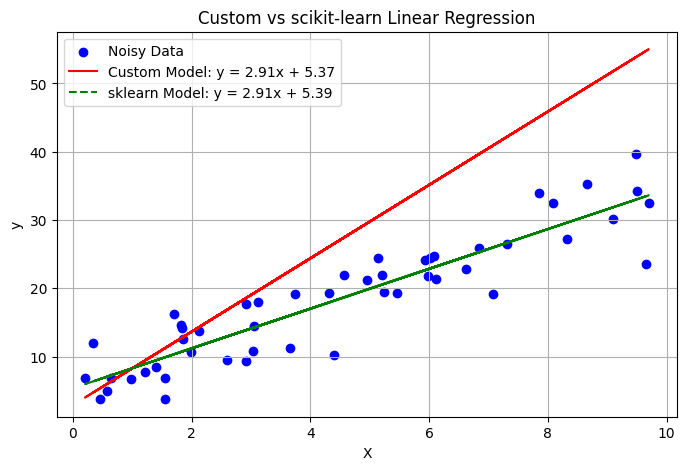

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Original noisy data
plt.scatter(X, y, label="Noisy Data", color='blue')

# Your model's line
plt.plot(X, y_pred_custom, label=f"Custom Model: y = {w_final:.2f}x + {b_final:.2f}", color='red')

# sklearn's model line
plt.plot(X, y_pred_sklearn, label=f"sklearn Model: y = {w_sklearn:.2f}x + {b_sklearn:.2f}", color='green', linestyle='--')

plt.xlabel("X")
plt.ylabel("y")
plt.title("Custom vs scikit-learn Linear Regression")
plt.legend()
plt.grid(True)
plt.show()
